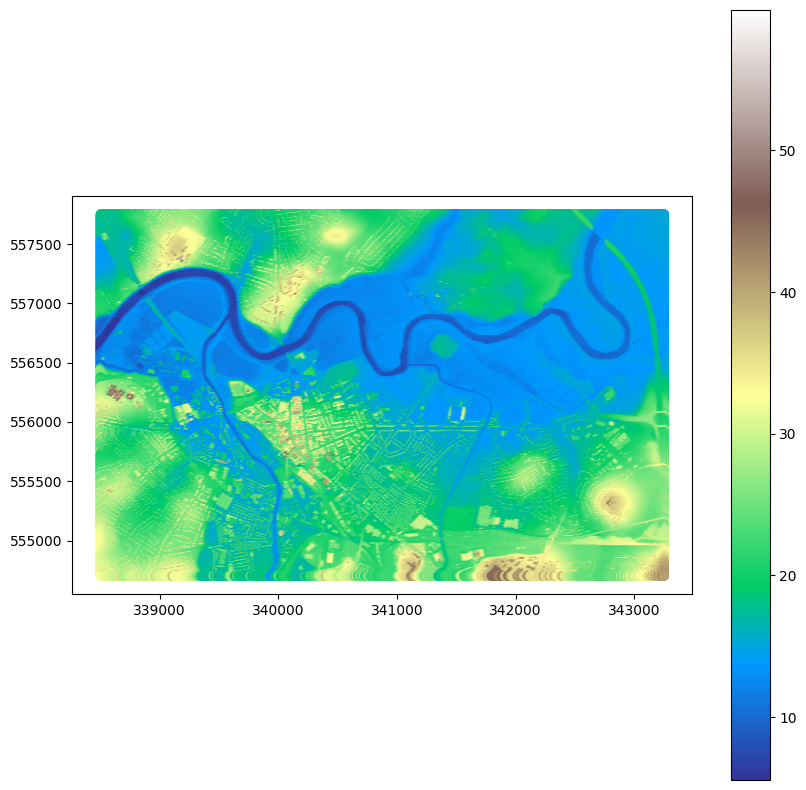

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import geometry
import rasterio as rio

def visualize_dem(file_path):
    with rio.open(file_path) as src:
        # Read the data
        data = src.read(1)  # Read the first band (elevation values)
        transform = src.transform  # Affine transform

    # Get the row, col indices of the array
    rows, cols = np.indices(data.shape)

    # Convert row, col to geographic coordinates
    xs, ys = rio.transform.xy(transform, rows, cols, offset='center')

    # Flatten the arrays for DataFrame creation
    xs_flat = np.array(xs).flatten()
    ys_flat = np.array(ys).flatten()
    data_flat = data.flatten()

    # Create a DataFrame
    df = pd.DataFrame({
        'x': xs_flat,
        'y': ys_flat,
        'elevation': data_flat
    })

    # Remove NoData values if needed (usually represented as a specific value, e.g., -9999)
    df = df[df['elevation'] != src.nodata]  # Adjust src.nodata if your NoData value is different

    # Save to CSV if needed
    df.to_csv('dem_dataframe.csv', index=False)

    # PLot the data on a map
    # Create a GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['x'], df['y']))

    # Plot the data
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf.plot(column='elevation', ax=ax, legend=True, cmap='terrain')
    plt.show()

file_path = '/Users/malintha/Documents/PHD/ARTEFACT1/TIME_SERIES_ML/Rapid_FloodModelling_CNN/Data/Carlisle_5m.asc'
visualize_dem(file_path)

In [1]:
import rasterio as rio
import pandas as pd
import os
import numpy as np
import psycopg2

def load_elevation_data():
    file_path = '/Users/malintha/Documents/PHD/ARTEFACT1/TIME_SERIES_ML/Rapid_FloodModelling_CNN/Data/Carlisle_5m.asc'
    with rio.open(file_path) as src:
        # Read the data
        data = src.read(1)
        transform = src.transform
        rows, cols = np.indices(data.shape)
        rows = rows.flatten()
        cols = cols.flatten()
        id = [f"{r}_{c}" for r, c in zip(rows, cols)]
        xs, ys = rio.transform.xy(transform, rows, cols, offset='center')
        xs_flat = np.array(xs).flatten()
        ys_flat = np.array(ys).flatten()
        data_flat = data.flatten()
        df = pd.DataFrame({
            'cell_id': id,
            'x_coordinate': xs_flat,
            'y_coordinate': ys_flat,
            'elevation': data_flat
        })
    return df

def load_data_batches(batch_size=10):
    print('Loading LISFLOOD data in batches')
    ## Initial Boundry Condition Data
    bc_data_dir = "/Users/malintha/Documents/PHD/ARTEFACT1/TIME_SERIES_ML/Rapid_FloodModelling_CNN/Data"
    csv_files = [file for file in os.listdir(bc_data_dir) if file.endswith('.csv')]
    csv_files.sort()

    ## LISFLOOD Simulation Data
    lisflood_simulation_dir = "/Users/malintha/Documents/PHD/ARTEFACT1/TIME_SERIES_ML/Rapid_FloodModelling_CNN/Data/simulation_output"
    inundation_files = {}
    for i in range(1, 3):
        inun_files = [file for file in os.listdir(lisflood_simulation_dir) if file.endswith('.wd') and file.startswith(f"Run{i}")]
        inundation_files[f"Run{i}"] = inun_files if len(inun_files) > 0 else []
    inun_files.sort()

    print(inundation_files)

    # Elevation Data
    elevation_df = load_elevation_data()
    elevation_df = elevation_df.set_index('cell_id')

    for key, inun_files in inundation_files.items():
        if len(inun_files) == 0:
            continue

        bc_file_name = [filename for filename in csv_files if key in filename][0]
        bc_df = pd.read_csv(os.path.join(bc_data_dir, bc_file_name))
        bc_df['timestep'] = ["Run" + str(csv_files.index(bc_file_name) + 1) + "_" + str(idx) for idx in bc_df.index]
        bc_df = bc_df.set_index('timestep')
        print(bc_df)

        # inun_files = inun_files[8:] 
        for i in range(0, len(inun_files), batch_size):
            batch_files = inun_files[i:i + batch_size]
            if len(batch_files) == 0:
                continue
            batch_data = []
            for file in batch_files:
                timestep = key + "_" + str(i)
                data = rio.open(os.path.join(lisflood_simulation_dir, file))
                values = data.read(1)
                rows, cols = np.indices(values.shape)
                rows = rows.flatten()
                cols = cols.flatten()
                depth = values.flatten()
                cell_ids = [f"{r}_{c}" for r, c in zip(rows, cols)]
                df = pd.DataFrame({'cell_id': cell_ids, 'depth': depth})
                df['timestep'] = timestep
                df.loc[df['depth'] < 0.3, 'depth'] = 0
                batch_data.append(df)
            target_df = pd.concat(batch_data, axis=0, ignore_index=True)
            print(target_df.shape)
            print(bc_df.shape)
            target_df['Upstream1'] = target_df['timestep'].map(bc_df['Upstream1'])
            target_df['Upstream2'] = target_df['timestep'].map(bc_df['Upstream2'])
            target_df['Upstream3'] = target_df['timestep'].map(bc_df['Upstream3'])
            target_df['elevation'] = target_df['cell_id'].map(elevation_df['elevation'])
            target_df['x_coordinate'] = target_df['cell_id'].map(elevation_df['x'])
            target_df['y_coordinate'] = target_df['cell_id'].map(elevation_df['y'])
            yield target_df

In [2]:
from dotenv import load_dotenv
import psycopg2
import os
from psycopg2.extras import execute_values

load_dotenv()
conn_params = {
    'dbname': 'carlisle_flood',
    'user': 'postgres',
    'password': os.getenv('POSTGRES_PASSWORD'),
    'host': 'localhost'
}

def db_execute(query):
    conn = psycopg2.connect(**conn_params)
    cur = conn.cursor()
    res = cur.execute(query)
    conn.commit()
    conn.close()
    return res
    

def create_database(db_name):
    """Create a new database with autocommit enabled"""
    conn = psycopg2.connect(**conn_params)
    conn.autocommit = True
    cur = conn.cursor()
    try:
        res = cur.execute(f"CREATE DATABASE {db_name}")
        print(f"Database {db_name} created successfully")
        return res
    except psycopg2.Error as e:
        print(f"Error creating database: {e}")
    finally:
        cur.close()
        conn.close()

def execute_many(query, data):
    conn = psycopg2.connect(**conn_params)
    cur = conn.cursor()
    cur.executemany(query, data)
    conn.commit()
    conn.close()

def execute_batch(query, data, template=None):
    conn = psycopg2.connect(**conn_params)
    cur = conn.cursor()
    execute_values(cur, query, data, template)
    conn.commit()
    conn.close()

In [3]:
# Insert data into elevation table
from shapely.geometry import Point

def insert_elevation_data():
    elevation_df = load_elevation_data()
    query = '''
        INSERT INTO elevation_data (geom, cell_id, x_coordinate, y_coordinate, elevation)
        VALUES %s;
    '''
    data = elevation_df.copy()
    data['geom'] = data.apply(lambda x: Point(x['x_coordinate'], x['y_coordinate']).wkt, axis=1)
    data = data[['geom', 'cell_id', 'x_coordinate', 'y_coordinate', 'elevation']]
    data = data.values
    template="(ST_GeomFromText(%s, 27700), %s, %s, %s, %s)"
    # data = [(f"ST_GeomFromText({row[0]}, 27700)", row[1], row[2], row[3], row[4]) for row in data]
    execute_batch(query, data, 'carlisle_flood')

# insert data into upstream conditions table
def insert_upstream_data():
    bc_data_dir = "/Users/malintha/Documents/PHD/ARTEFACT1/TIME_SERIES_ML/Rapid_FloodModelling_CNN/Data"
    csv_files = [file for file in os.listdir(bc_data_dir) if file.endswith('.csv')]
    csv_files.sort()
    query = '''
        INSERT INTO upstream_conditions (timestep, upstream1, upstream2, upstream3)
        VALUES (%s, %s, %s, %s);
    '''
    for idx, file in enumerate(csv_files):
        print(f"Processing file {idx}")
        bc_df = pd.read_csv(os.path.join(bc_data_dir, file))
        bc_df['timestep'] = ["Run" + str(csv_files.index(file) + 1) + "_" + str(idx) for idx in bc_df.index]
        bc_df = bc_df.set_index('timestep')
        bc_df = bc_df[['Upstream1', 'Upstream2', 'Upstream3']]
        bc_df = bc_df.dropna()
        bc_df = bc_df.reset_index()
        bc_df = bc_df.values
        print(len(bc_df))
        execute_many(query, bc_df, 'carlisle_flood')

def insert_simulation_data():
    lisflood_simulation_dir = "/Users/malintha/Documents/PHD/ARTEFACT1/TIME_SERIES_ML/Rapid_FloodModelling_CNN/Data/simulation_output"
    inundation_files = {}
    for i in range(1, 3):
        inun_files = [file for file in os.listdir(lisflood_simulation_dir) if file.endswith('.wd') and file.startswith(f"Run{i}")]
        inundation_files[f"Run{i}"] = inun_files if len(inun_files) > 0 else []
    inun_files.sort()

    query = '''
        INSERT INTO simulation_data (cell_id, depth, timestep)
        VALUES %s
    '''

    for key, inun_files in inundation_files.items():
        if len(inun_files) == 0:
            continue

        for i in range(0, len(inun_files)):
            print(f"Processing file {i}")
            file = inun_files[i]
            timestep = key + "_" + str(i)
            data = rio.open(os.path.join(lisflood_simulation_dir, file))
            values = data.read(1)
            rows, cols = np.indices(values.shape)
            rows = rows.flatten()
            cols = cols.flatten()
            depth = values.flatten()
            cell_ids = [f"{r}_{c}" for r, c in zip(rows, cols)]
            df = pd.DataFrame({'cell_id': cell_ids, 'depth': depth})
            df['timestep'] = timestep
            df.loc[df['depth'] < 0.3, 'depth'] = 0
            df = df.dropna()
            df = df[['cell_id', 'depth', 'timestep']]
            df = df.values
            print(df.shape)
            execute_batch(query, df, 'carlisle_flood')

In [ ]:

# Create a table named 'flood_data'
# create_table_query = '''
#     CREATE TABLE IF NOT EXISTS lisflood_data (
#         id SERIAL PRIMARY KEY,
#         geom GEOMETRY(Point,27700),
#         cell_id VARCHAR(255),
#         depth FLOAT,
#         timestep VARCHAR(255),
#         upstream1 FLOAT,
#         upstream2 FLOAT,
#         upstream3 FLOAT,
#         elevation FLOAT
#     )
# '''


# Create separate tables for upstream conditions, elevation and simulation data
create_upstream_table_query = '''
    CREATE TABLE IF NOT EXISTS upstream_conditions (
        id SERIAL PRIMARY KEY,
        timestep VARCHAR(255),
        upstream1 FLOAT,
        upstream2 FLOAT,
        upstream3 FLOAT
    )
'''

create_elevation_table_query = '''
    CREATE TABLE IF NOT EXISTS elevation_data (
        id SERIAL PRIMARY KEY,
        geom GEOMETRY(Point,27700),
        cell_id VARCHAR(255),
        x_coordinate FLOAT,
        y_coordinate FLOAT,
        elevation FLOAT
    )
'''

create_simulation_table_query = '''
    CREATE TABLE IF NOT EXISTS simulation_data (
        id SERIAL PRIMARY KEY,
        cell_id VARCHAR(255),
        depth FLOAT,
        timestep VARCHAR(255)
    )
'''

drop_table_upstream = ''' DROP TABLE IF EXISTS upstream_conditions'''
drop_table_elevation = ''' DROP TABLE IF EXISTS elevation_data'''
drop_table_simulation = ''' DROP TABLE IF EXISTS simulation_data'''

# Enable PostGIS extension
enable_postgis_query = "CREATE EXTENSION IF NOT EXISTS postgis"

def initialise_db():
    db_execute(enable_postgis_query)
    db_execute(drop_table_upstream)
    db_execute(drop_table_elevation)
    db_execute(drop_table_simulation)
    db_execute(create_upstream_table_query)
    db_execute(create_elevation_table_query)
    db_execute(create_simulation_table_query)

In [ ]:
# def insert_data(generator): 
#     query = '''
#         INSERT INTO lisflood_data (geom, cell_id, depth, timestep, upstream1, upstream2, upstream3, elevation)
#         VALUES (ST_GeomFromText(%s, 27700), %s, %s, %s, %s, %s, %s, %s)
#     '''

#     for idx, data in enumerate(generator):
#         print(f"Processing batch {idx}")
#         data['geom'] = data.apply(lambda x: f"POINT({x['x_coordinate']} {x['y_coordinate']})", axis=1)
#         data = data.drop(columns=['x_coordinate', 'y_coordinate'])
#         data = data[['geom', 'cell_id', 'depth', 'timestep', 'Upstream1', 'Upstream2', 'Upstream3', 'elevation']]
#         data = data.dropna()
#         data = data.values
#         data = data[:1000]
#         execute_many(query, data, 'carlisle_flood')

# generator = load_data_batch(1)
# insert_data(generator)

#initialise_db()
#insert_elevation_data()
#db_execute(drop_table_query4, 'carlisle_flood')
#db_execute(create_simulation_table_query, 'carlisle_flood')
#insert_simulation_data()
# insert_elevation_data()

In [7]:
import psycopg2
import pandas as pd
from shapely.geometry import box, Point
from typing import List, Union

def get_random_points(conn_params: dict, n_points: int = 1000) -> List[Point]:
    """Get n random points from the flood database"""
    
    query = """
    SELECT DISTINCT ON (cell_id) 
           ST_X(geom) as x, 
           ST_Y(geom) as y
    FROM elevation_data
    ORDER BY cell_id, random()
    LIMIT %s
    """
    conn = psycopg2.connect(**conn_params)
    df = pd.read_sql(query, conn, params=[n_points])
    conn.close()
    
    # Convert to list of Points
    points = [Point(row.x, row.y) for _, row in df.iterrows()]
    return points

def get_spatial_data(conn_params: dict, 
                    spatial_filter: Union[box, List[Point]], 
                    timesteps: List[str] = None):
    """
    Query database within spatial bounds
    """
    conn = psycopg2.connect(**conn_params)
    points_wkt = ", ".join([f"POINT({p.x} {p.y})" for p in spatial_filter])
    geom_filter = f"ST_Collect(ARRAY[{', '.join([f'ST_GeomFromText(\'{p}\', 27700)' for p in points_wkt.split(', ')])}])"

    RANDOM_QUERY = f"""
    SELECT cell_id, depth, timestep, upstream1, upstream2, upstream3, elevation,
           ST_X(geom) as x, ST_Y(geom) as y
    FROM simulation_data JOIN elevation_data USING (cell_id) JOIN upstream_conditions USING (timestep)
    WHERE ST_Within(elevation_data.geom, {geom_filter})
    """

    if timesteps:
        RANDOM_QUERY += " AND timestep = ANY(%s)"
        params = [timesteps]
    else:
        params = []

    # query += " ORDER BY cell_id, timestep"
    
    df = pd.read_sql(RANDOM_QUERY, conn, params=params)
    conn.close()
    return df

def stream_spatial_data(conn_params: dict, chunk_size: int = 1000, shuffle: bool = False, flood_event: str = None):
    """
    Stream spatial data in chunks using pandas iterator
    
    Args:
        conn_params (dict): Database connection parameters
        chunk_size (int): Size of each chunk to stream
        shuffle (bool): Whether to randomize the data
    
    Yields:
        pandas.DataFrame: Chunk of spatial data
    """
    conn = None
    try:
        conn = psycopg2.connect(**conn_params)
        
        query = """
        SELECT cell_id, timestep, elevation, ST_X(geom) as x, ST_Y(geom) as y, upstream1, upstream2, upstream3, depth
               
        FROM simulation_data JOIN elevation_data USING (cell_id) JOIN upstream_conditions USING (timestep) 
        """
        if flood_event:
            query += f" AND timestep LIKE '%{flood_event}%'"
        if shuffle:
            query += " ORDER BY RANDOM()"
        else:
            query += " ORDER BY cell_id, timestep"
            
        # Create iterator
        chunks = pd.read_sql(
            query,
            conn,
            chunksize=chunk_size
        )
        
        # Yield chunks
        for chunk in chunks:
            yield chunk
            
    except Exception as e:
        print(f"Error streaming data: {e}")
        raise
    finally:
        if conn:
            conn.close()

In [8]:
generator  = stream_spatial_data(conn_params, chunk_size=10)
for idx, chunk in enumerate(generator):
    print(f"Processing chunk {idx}")
    print(chunk.head())
    break

/var/folders/k1/lxcg1_g5593dy1ljsl153gyw0000gn/T/ipykernel_9916/4088340573.py:82: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  chunks = pd.read_sql(


Processing chunk 0
  cell_id  depth timestep  upstream1  upstream2  upstream3  elevation  \
0     0_0    0.0   Run1_0      1.000    0.12000     1.2000  18.480000   
1     0_0    0.0   Run1_1     26.743    0.64858     1.2318  18.480000   
2     0_1    0.0   Run1_0      1.000    0.12000     1.2000  18.209999   
3     0_1    0.0   Run1_1     26.743    0.64858     1.2318  18.209999   
4    0_10    0.0   Run1_0      1.000    0.12000     1.2000  17.760000   

          x         y  
0  338502.5  557752.5  
1  338502.5  557752.5  
2  338507.5  557752.5  
3  338507.5  557752.5  
4  338552.5  557752.5  


In [ ]:
points = get_random_points(conn_params)
print("got points")
point_data = get_spatial_data(conn_params, points)

/var/folders/k1/lxcg1_g5593dy1ljsl153gyw0000gn/T/ipykernel_18789/1935064941.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=[n_points])
/var/folders/k1/lxcg1_g5593dy1ljsl153gyw0000gn/T/ipykernel_18789/1935064941.py:50: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(RANDOM_QUERY, conn, params=params)


In [57]:
point_data

,cell_id,depth,timestep,upstream1,upstream2,upstream3,elevation,x,y
0,0_0,0.0,Run1_0,1.000,0.12000,1.2000,18.480000,338502.5,557752.5
1,0_1,0.0,Run1_0,1.000,0.12000,1.2000,18.209999,338507.5,557752.5
2,0_10,0.0,Run1_0,1.000,0.12000,1.2000,17.760000,338552.5,557752.5
3,0_100,0.0,Run1_0,1.000,0.12000,1.2000,25.000000,339002.5,557752.5
4,0_101,0.0,Run1_0,1.000,0.12000,1.2000,24.990000,339007.5,557752.5
5,0_102,0.0,Run1_0,1.000,0.12000,1.2000,25.100000,339012.5,557752.5
6,0_103,0.0,Run1_0,1.000,0.12000,1.2000,25.240000,339017.5,557752.5
7,0_104,0.0,Run1_0,1.000,0.12000,1.2000,26.600000,339022.5,557752.5
8,0_105,0.0,Run1_0,1.000,0.12000,1.2000,25.209999,339027.5,557752.5
9,0_106,0.0,Run1_0,1.000,0.12000,1.2000,25.240000,339032.5,557752.5


In [38]:
import numpy as np
from tensorflow.keras.utils import Sequence

class FloodDataGenerator(Sequence):
    """
    Data generator for flood forecasting with temporal sequences
    """
    def __init__(self, data_stream, batch_size=32, lag=7, horizon=1, shuffle=True):
        self.data_stream = data_stream
        self.batch_size = batch_size
        self.lag = lag
        self.horizon = horizon
        self.shuffle = shuffle
        self.conn_params = {
            'dbname': 'carlisle_flood',
            'user': 'postgres',
            'host': 'localhost',
            'password': os.getenv('POSTGRES_PASSWORD')
        }

    def __len__(self):
        # Get total number of sequences
        conn = psycopg2.connect(**self.conn_params)
        query = "SELECT COUNT(DISTINCT cell_id) FROM simulation_data"
        count = pd.read_sql(query, conn).iloc[0,0]
        conn.close()
        return int(np.ceil(count / self.batch_size))

    def __getitem__(self):
        # Get batch of sequences
        batch_data = next(self.data_stream)
        
        # Create sequences
        X, y = [], []
        for cell_id in batch_data['cell_id'].unique():
            print(f"Processing cell {cell_id}")
            cell_data = batch_data[batch_data['cell_id'] == cell_id].sort_values('timestep')
            
            # Create sequences with lag and horizon
            for i in range(0, cell_data.shape[0] - self.lag, 1):
                X_seq = cell_data.iloc[i:(i + self.lag)][['depth', 'upstream1', 'upstream2', 'upstream3', 'elevation', 'x', 'y']]
                y_seq = cell_data.iloc[i + self.lag:i + self.lag + self.horizon]['depth']               
                X.append(X_seq)
                y.append(y_seq)
        return np.array(X), np.array(y) 

In [39]:
# Usage with model.fit():
data_gen = FloodDataGenerator(
    data_stream=stream_spatial_data(conn_params, chunk_size=6),
    batch_size=32,
    lag=1,
    horizon=1
)

In [40]:
x,y = data_gen.__getitem__()

/var/folders/k1/lxcg1_g5593dy1ljsl153gyw0000gn/T/ipykernel_9916/4088340573.py:82: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  chunks = pd.read_sql(


  cell_id  depth timestep  upstream1  upstream2  upstream3  elevation  \
0     0_0    0.0   Run1_0      1.000    0.12000     1.2000  18.480000   
1     0_0    0.0   Run1_1     26.743    0.64858     1.2318  18.480000   
2     0_1    0.0   Run1_0      1.000    0.12000     1.2000  18.209999   
3     0_1    0.0   Run1_1     26.743    0.64858     1.2318  18.209999   
4    0_10    0.0   Run1_0      1.000    0.12000     1.2000  17.760000   

          x         y  
0  338502.5  557752.5  
1  338502.5  557752.5  
2  338507.5  557752.5  
3  338507.5  557752.5  
4  338552.5  557752.5  
Processing cell 0_0
cell_shape (2, 9)
X sequence    depth  upstream1  upstream2  upstream3  elevation         x         y
0    0.0        1.0       0.12        1.2      18.48  338502.5  557752.5
Y_sequence 1    0.0
Name: depth, dtype: float64
Processing cell 0_1
cell_shape (2, 9)
X sequence    depth  upstream1  upstream2  upstream3  elevation         x         y
2    0.0        1.0       0.12        1.2  18.209999

In [ ]:
# Train model
# model.fit(
#     data_gen,
#     epochs=10,
#     steps_per_epoch=len(data_gen),
#     validation_data=validation_gen,
#     validation_steps=len(validation_gen)
# )